In [34]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Job\Aston_University\EuroSAT\notebooks


In [35]:
from pathlib import Path
from PIL import Image
from src.config import *
from src.utils import *
from src.visualisation import *
from src.dataloader import *
from src.statistics import *
from src.transforms import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch

# Load CSV

In [3]:
train_df, val_df, test_df = load_dataset_splits()

In [ ]:
train_df.shape, test_df.shape, val_df.shapea

((18360, 4), (3240, 4), (5400, 4))

In [5]:
train_df.head()

,path_rgb,label,image_id,path_ms
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Highway,Highway_943,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,PermanentCrop,PermanentCrop_929,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_245,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,River,River_1950,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,PermanentCrop,PermanentCrop_1326,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...


# Class Mappings

In [6]:
CLASSES = sorted(train_df['label'].unique())

class_to_idx, idx_to_class = map_labels(CLASSES)

NUM_CLASSES = len(CLASSES)

print('Total Classes : ', NUM_CLASSES)
print('Class to Index : ', class_to_idx)
print('Index to Class : ', idx_to_class)

Total Classes :  10
Class to Index :  {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}
Index to Class :  {0: 'AnnualCrop', 1: 'Forest', 2: 'HerbaceousVegetation', 3: 'Highway', 4: 'Industrial', 5: 'Pasture', 6: 'PermanentCrop', 7: 'Residential', 8: 'River', 9: 'SeaLake'}


In [7]:
train_df['idx'] = train_df['label'].map(class_to_idx)
test_df['idx'] = test_df['label'].map(class_to_idx)
val_df['idx'] = val_df['label'].map(class_to_idx)

train_df.head()

,path_rgb,label,image_id,path_ms,idx
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Highway,Highway_943,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,3
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,PermanentCrop,PermanentCrop_929,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,6
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_245,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,River,River_1950,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,8
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,PermanentCrop,PermanentCrop_1326,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,6


In [8]:
val_df.head()

,path_rgb,label,image_id,path_ms,idx
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Pasture,Pasture_271,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,5
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop,AnnualCrop_1683,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Industrial,Industrial_2479,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,4
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Highway,Highway_2248,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,3
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,Highway,Highway_136,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,3


In [9]:
train_df.to_csv(SPLITS_DIR / 'train.csv', index=False)
test_df.to_csv(SPLITS_DIR / 'val.csv', index=False)
val_df.to_csv(SPLITS_DIR / 'test.csv', index=False)

# Transforms

In [10]:
train_transform, eval_transform = get_rgb_transforms()

Tensor Shape :  torch.Size([3, 64, 64])
Tensor Type:  torch.float32
Min : tensor(0.)
Max :  tensor(0.8706)
Image Size :  (64, 64)


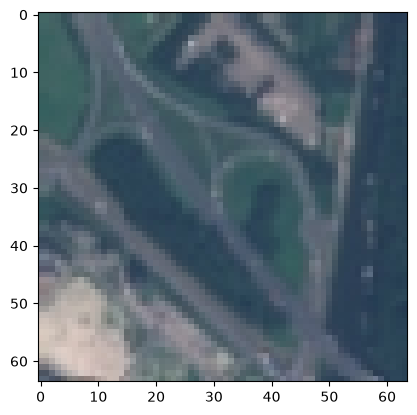

In [11]:
# Testing the Transforms - Display RGB Images

sample = train_df.iloc[0]['path_rgb']

sample_img = Image.open(sample).convert('RGB')

sample_tensor = train_transform(sample_img)

print('Tensor Shape : ', sample_tensor.shape)
print('Tensor Type: ', sample_tensor.dtype)
print('Min :', sample_tensor.min())
print('Max : ', sample_tensor.max())
print('Image Size : ', sample_img.size)

plt.imshow(sample_img)


# RGB - Preprocessing

In [12]:
# Temporary Dataset Transforms and Loader
 
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from src.datasets import *
from PIL import Image
import torch

temp_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Temporary DatasetClass
class RGBNormDataset(Dataset):
    def __init__(self, df, transform=None):
        self.dataframe = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx]['path_rgb']
        image_label = self.dataframe.iloc[idx]['label']

        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image
    
temp_dataset = RGBNormDataset(train_df, temp_transform)

temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=0)


In [13]:
#  Calculating Mean and Standard Deviation for Normalisation

RGB_MEAN, RGB_STD = mean_std_calc(temp_loader, 3)

print('RGB MEAN : ', RGB_MEAN)
print('RGB Standard Deviation : ', RGB_STD)

MEAN :  tensor([0.3438, 0.3799, 0.4075], dtype=torch.float64)
Standard Deviation :  tensor([0.2022, 0.1365, 0.1153], dtype=torch.float64)
RGB MEAN :  [0.3437961823540316, 0.37985810236214035, 0.40751632719517794]
RGB Standard Deviation :  [0.20219254157101516, 0.13648250584592042, 0.11525466355998704]


In [14]:

train_transform, eval_transform = get_rgb_transforms(RGB_MEAN, RGB_STD)

In [15]:
train_rgb_dataset = RGBDataset(train_df, train_transform)

val_rgb_dataset = RGBDataset(val_df, eval_transform)

test_rgb_dataset = RGBDataset(test_df, eval_transform)


In [16]:
# Testing one sample

images_rgb, label_rgb = train_rgb_dataset[0]

print('Image Shape : ', images_rgb.shape)
print('Image Type : ', images_rgb.dtype)
print('Label : ', label_rgb)
print('Label Index : ', idx_to_class[label_rgb])

Image Shape :  torch.Size([3, 64, 64])
Image Type :  torch.float32
Label :  3
Label Index :  Highway


In [17]:

train_rgb_loader, val_rgb_loader, test_rgb_loader = get_dataloader(train_rgb_dataset, val_rgb_dataset, test_rgb_dataset)

# Testing one sample

images_rgb, labels = next(iter(train_rgb_loader))

print('Image Shape : ', images_rgb.shape)
print('Image Type : ', images_rgb.dtype)
print('Labels : ', labels)
print('Label no :', labels.shape)


Image Shape :  torch.Size([64, 3, 64, 64])
Image Type :  torch.float32
Labels :  tensor([7, 9, 6, 1, 9, 8, 4, 7, 9, 9, 1, 1, 9, 3, 7, 9, 1, 1, 8, 0, 2, 6, 7, 5,
        1, 2, 0, 3, 3, 8, 4, 0, 4, 1, 1, 8, 1, 6, 4, 3, 7, 9, 0, 2, 2, 6, 2, 6,
        4, 7, 2, 2, 4, 8, 4, 5, 3, 7, 9, 9, 7, 1, 3, 9])
Label no : torch.Size([64])


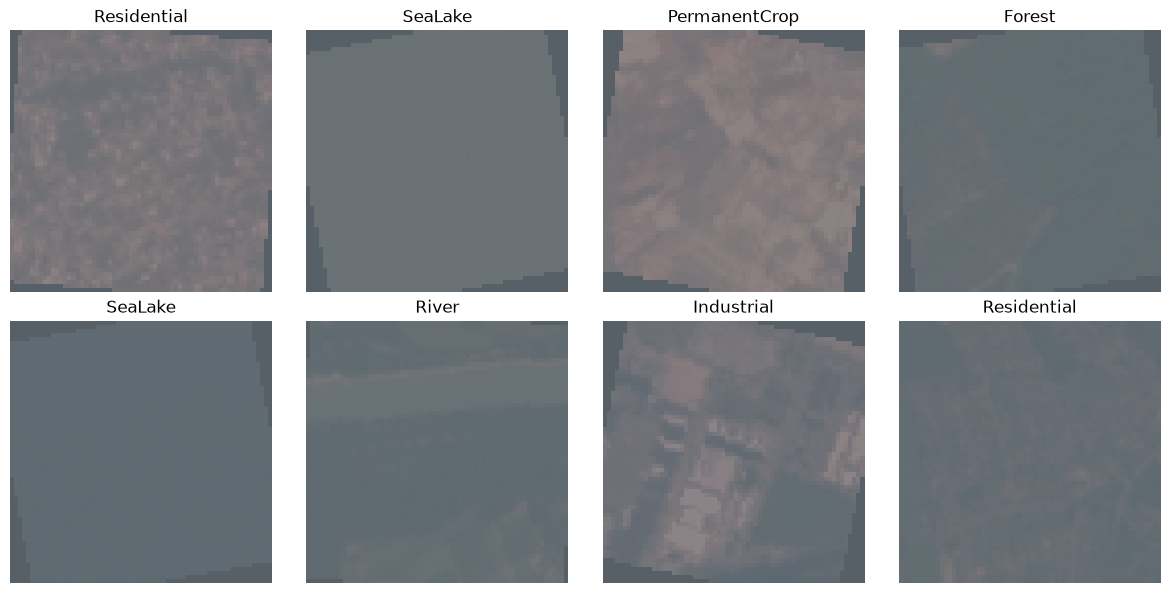

In [18]:
# Visualising the Images

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

mean_rgb = torch.tensor(RGB_MEAN).view(3, 1, 1)
std_rgb = torch.tensor(RGB_STD).view(3, 1, 1)

for ax, image, label in zip(axes.flat, images_rgb[:8], labels[:8]):
    image = image * std_rgb + mean_rgb  # Denormalisation
    image = image.clamp(0,1)
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(idx_to_class[label.item()])
    ax.axis('off')

plt.savefig(RAW_RGB_IMGS, dpi=300)

plt.tight_layout()
plt.show()

# MS Dataset - Additional EDA

In [19]:
# MS Bands Statistics

no_samples = 200

sample_ms_df = (train_df.groupby('label', group_keys=False)
                .apply(lambda group: group.sample(n=min(no_samples, len(group)),
                                                  random_state=42))
                .reset_index(drop=True)
                )

sample_ms_df

,path_rgb,image_id,path_ms,idx
0,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop_2135,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
1,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop_460,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
2,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop_262,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
3,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop_2093,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
4,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,AnnualCrop_255,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,0
...,...,...,...,...
1995,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,SeaLake_2514,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,9
1996,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,SeaLake_860,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,9
1997,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,SeaLake_642,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,9
1998,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,SeaLake_2500,D:\Anisha\Job\Aston_University\EuroSAT\data\ra...,9


In [20]:
band_values = [[] for _ in range(NUM_BANDS)]

for image_path in sample_ms_df['path_ms']:
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32)

    for band_idx in range(NUM_BANDS):
        band_values[band_idx].append(image[band_idx].ravel())

print('Number of Bands :', len(band_values))
print('Number of Images for Bands :', len(band_values[0]))
print('Image Band Pixels :', band_values[0][0].shape)
print(band_values)

Number of Bands : 13
Number of Images for Bands : 2000
Image Band Pixels : (4096,)
[[array([1296., 1296., 1293., ..., 1247., 1247., 1247.],
      shape=(4096,), dtype=float32), array([1198., 1198., 1199., ..., 1465., 1483., 1500.],
      shape=(4096,), dtype=float32), array([1391., 1391., 1385., ..., 1247., 1247., 1247.],
      shape=(4096,), dtype=float32), array([1528., 1528., 1521., ..., 1538., 1537., 1537.],
      shape=(4096,), dtype=float32), array([1189., 1189., 1190., ..., 1440., 1419., 1399.],
      shape=(4096,), dtype=float32), array([1578., 1578., 1586., ..., 1428., 1426., 1424.],
      shape=(4096,), dtype=float32), array([1304., 1304., 1302., ..., 1318., 1318., 1318.],
      shape=(4096,), dtype=float32), array([1452., 1452., 1443., ..., 1287., 1286., 1286.],
      shape=(4096,), dtype=float32), array([1142., 1142., 1143., ..., 1504., 1505., 1505.],
      shape=(4096,), dtype=float32), array([1553., 1553., 1560., ..., 1310., 1336., 1365.],
      shape=(4096,), dtype=float

In [21]:
# Statistics                    #ANI should i check 1th and 99th instead? (CHECK)


band_statistics = get_band_statistics(band_values)

print(band_statistics.shape)

display(band_statistics)

# Saving the Statistics

METRICS_PATH.mkdir(parents=True, exist_ok=True)

(13, 8)


,band_index,mean,std,min,p1,median,p99,max
0,1,1358.266235,245.558624,842.0,982.0,1314.0,2105.0,5423.0
1,2,1122.788330,337.851135,1.0,703.0,1048.0,2276.0,21504.0
2,3,1048.920166,397.693604,1.0,457.0,977.0,2361.0,28000.0
3,4,954.500061,594.718628,1.0,241.0,803.0,2841.0,28000.0
4,5,1208.460693,562.330811,182.0,202.0,1147.0,2850.0,13769.0
5,6,2023.087036,855.641663,158.0,177.0,2110.0,3911.0,15743.0
6,7,2398.878418,1082.391846,130.0,156.0,2474.0,4927.0,17755.0
7,8,2326.022705,1117.579590,18.0,129.0,2412.0,4858.0,28000.0
8,9,739.162598,403.847992,43.0,56.0,716.0,1872.0,2598.0
9,10,12.060602,4.591655,2.0,5.0,11.0,28.0,109.0


    band_index         mean          std    min     p1  median     p99  \
0            1  1358.266235   245.558624  842.0  982.0  1314.0  2105.0   
1            2  1122.788330   337.851135    1.0  703.0  1048.0  2276.0   
2            3  1048.920166   397.693604    1.0  457.0   977.0  2361.0   
3            4   954.500061   594.718628    1.0  241.0   803.0  2841.0   
4            5  1208.460693   562.330811  182.0  202.0  1147.0  2850.0   
5            6  2023.087036   855.641663  158.0  177.0  2110.0  3911.0   
6            7  2398.878418  1082.391846  130.0  156.0  2474.0  4927.0   
7            8  2326.022705  1117.579590   18.0  129.0  2412.0  4858.0   
8            9   739.162598   403.847992   43.0   56.0   716.0  1872.0   
9           10    12.060602     4.591655    2.0    5.0    11.0    28.0   
10          11  1844.102051   999.144897    5.0   21.0  1835.0  4182.0   
11          12  1130.379150   757.436829    1.0   11.0  1038.0  3117.0   
12          13  2627.562744  1224.9927

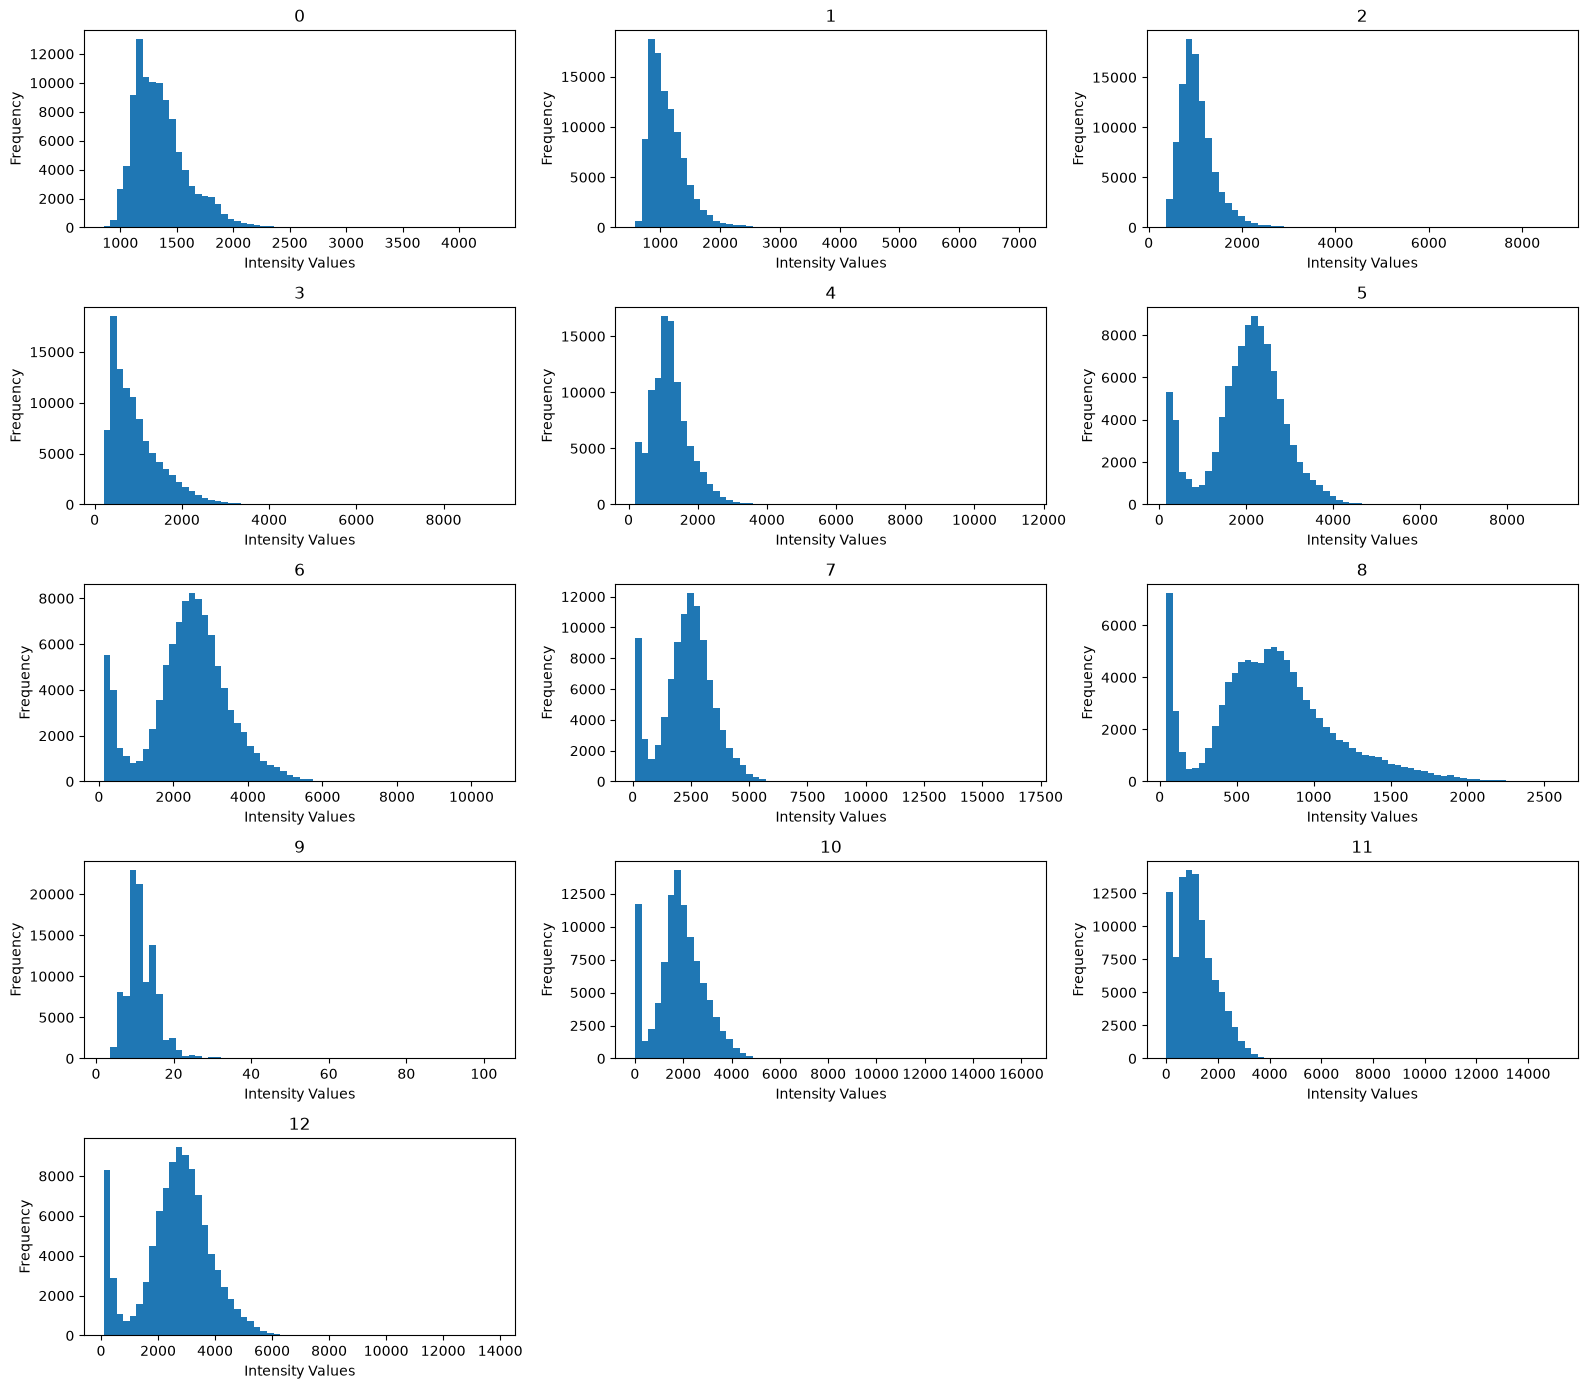

In [22]:
# Plot Statistics

band_statistics['band_name'] = BAND_NAMES

print(band_statistics)

band_statistics.to_csv(EDA_PATH / 'ms_band_statistics.csv', index = False)

fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.flatten()

max_val = 100000
rng = np.random.default_rng(42)

for band_idx, arrays in enumerate(band_values):
    values = np.concatenate(arrays)

    if len(values) > max_val:
        plot_values = rng.choice(values, size=max_val, replace=False)
    else:
        plot_values = values

    axes[band_idx].hist(plot_values, bins=60)
    axes[band_idx].set_title(band_idx)
    axes[band_idx].set_xlabel('Intensity Values')
    axes[band_idx].set_ylabel('Frequency')

for ax in axes[13:]:
    ax.axis('off')

plt.savefig(BAND_STATISTICS_IMG, dpi=300)
plt.tight_layout()
plt.show()

# MS Dataset - Preprocessing

In [23]:
import rasterio

class MSNormDataset(Dataset):
    def __init__(self, df):
        self.dataframe = df.reset_index(drop=True)

    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = self.dataframe.iloc[idx]['path_ms']

        with rasterio.open(image_path) as src:
            image = src.read()

        image = torch.from_numpy(image).float()

        return image
    
temp_ms_dataset = MSNormDataset(train_df)

temp_ms_loader = DataLoader(temp_ms_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)



In [24]:
#  Calculating Mean and Standard Deviation for Normalisation

MS_MEAN, MS_STD = mean_std_calc(temp_ms_loader, 13)

print('MS MEAN : ', MS_MEAN)
print('MS Standard Deviation : ', MS_STD)

MEAN :  tensor([1353.2550, 1116.4880, 1040.6884,  944.9007, 1196.9273, 1999.9567,
        2370.7713, 2298.0348,  730.8045,   12.0943, 1819.6793, 1116.7829,
        2596.4063], dtype=torch.float64)
Standard Deviation :  tensor([ 244.7415,  332.4079,  393.9845,  593.0378,  565.7754,  860.0764,
        1086.2763, 1117.9362,  403.6987,    4.7458, 1003.4484,  759.6896,
        1231.1769], dtype=torch.float64)
MS MEAN :  [1353.25495898012, 1116.4880467898965, 1040.6883869910812, 944.9007076354848, 1196.9272926879084, 1999.9567299836601, 2370.7713273590684, 2298.034763071895, 730.8044630395561, 12.094276139003778, 1819.6792743225762, 1116.7829329214326, 2596.4063061683005]
MS Standard Deviation :  [244.7414835566127, 332.40788456934314, 393.984502151689, 593.0377948583373, 565.7753761699353, 860.0764404527213, 1086.276284220411, 1117.9362223365024, 403.6986595426083, 4.745812566575351, 1003.4483776766317, 759.6896027326612, 1231.1769205233466]


In [25]:

train_ms_transform, eval_ms_transform = get_ms_transforms(MS_MEAN, MS_STD)

In [26]:
# Testing one sample

train_ms_dataset = MSDataset(train_df, train_ms_transform)

val_ms_dataset = MSDataset(val_df, eval_ms_transform)

test_ms_dataset = MSDataset(test_df, eval_ms_transform)


image_ms, label = train_ms_dataset[0]

print('Length of Train MS Dataset : ', len(train_ms_dataset))
print('Image Shape : ', image_ms.shape)
print('Image Type : ', image_ms.dtype)
print('Label : ', label)
print('Label Index : ', idx_to_class[label])

Length of Train MS Dataset :  18360
Image Shape :  torch.Size([13, 64, 64])
Image Type :  torch.float32
Label :  3
Label Index :  Highway


In [27]:
train_ms_loader, val_ms_loader, test_ms_loader = get_dataloader(train_ms_dataset, val_ms_dataset, test_ms_dataset)

# Testing one sample

images, labels = next(iter(train_ms_loader))

print('Image Shape : ', images.shape)
print('Image Type : ', images.dtype)
print('Labels : ', labels)
print('Label no :', labels.shape)

Image Shape :  torch.Size([64, 13, 64, 64])
Image Type :  torch.float32
Labels :  tensor([3, 7, 2, 5, 5, 8, 4, 9, 1, 5, 0, 4, 8, 9, 1, 3, 5, 3, 6, 4, 6, 1, 9, 1,
        7, 9, 9, 4, 7, 2, 5, 1, 3, 8, 3, 9, 0, 1, 7, 5, 3, 3, 5, 8, 8, 0, 0, 1,
        0, 9, 7, 1, 9, 7, 0, 9, 5, 5, 4, 0, 2, 0, 1, 0])
Label no : torch.Size([64])


In [36]:
import src.config
import importlib

importlib.reload(src.config)

<module 'src.config' from 'd:\\Anisha\\Job\\Aston_University\\EuroSAT\\src\\config.py'>

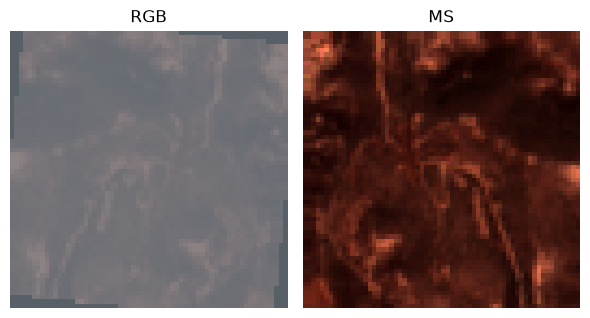

In [37]:

rnd_val = np.random.randint(len(train_ms_dataset))

# Validating RGB and MS

image_rgb, label = train_rgb_dataset[rnd_val]
image_rgb = image_rgb * std_rgb + mean_rgb  # Denormalisation
image_rgb = image_rgb.clamp(0,1)
image_rgb = image_rgb.permute(1, 2, 0)

image_ms, label_ms = train_ms_dataset[rnd_val]

mean_ms = torch.tensor(MS_MEAN, dtype=torch.float32).view(13, 1, 1)
std_ms = torch.tensor(MS_STD, dtype=torch.float32).view(13, 1, 1)

image_ms = image_ms * std_ms + mean_ms  # Denormalisation
# image_ms = image_ms.clamp(0,1)
# image_ms = image_ms.permute(1, 2, 0)


new_band = [image_ms[3], image_ms[2], image_ms[1]]
ms_im8 = ms_visualisation_uint8(new_band)
    

fig, axes = plt.subplots(1, 2, figsize=(6,6))

for ax, image, label in zip(axes.flat, [image_rgb, ms_im8], ['RGB', 'MS']):
    
    ax.imshow(image)
    ax.set_title(label)
    ax.axis('off')

plt.savefig(RECONSTRUCTED_RGB_MS, dpi=300)

plt.tight_layout()
plt.show()


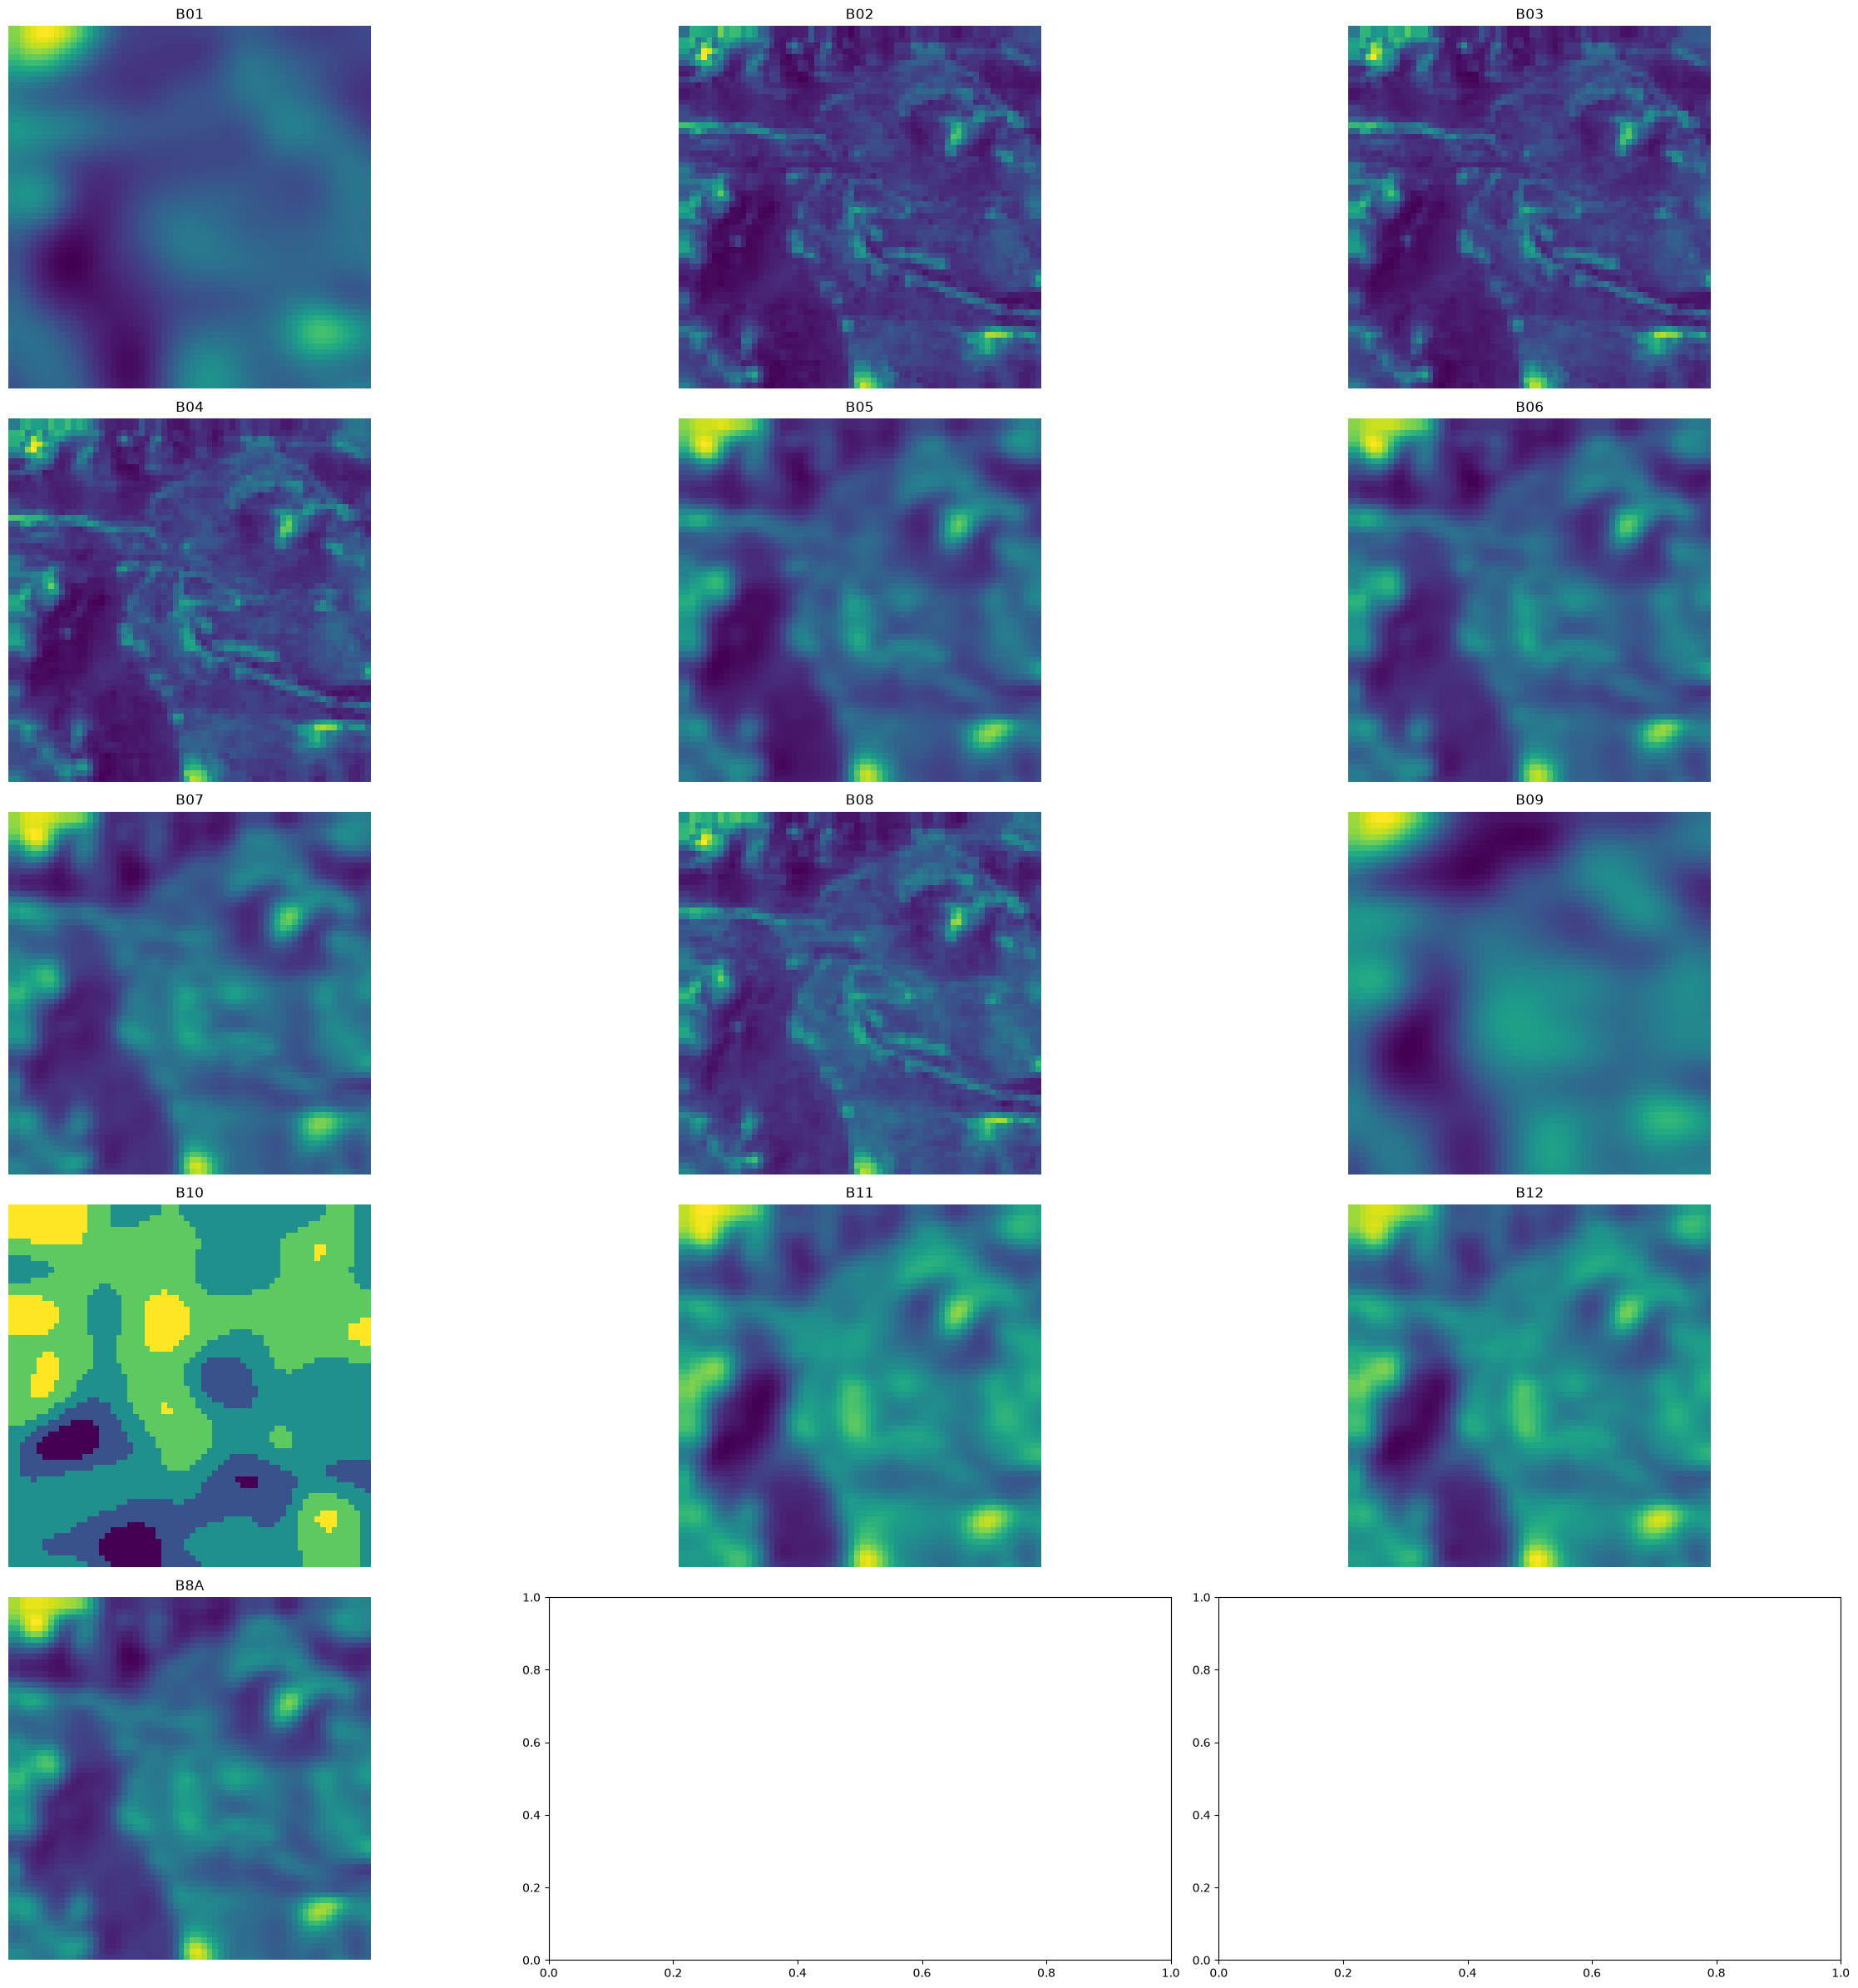

In [38]:
# Single Band Check

new_band = [image_ms[i] for i in range(NUM_BANDS)]

fig, axes = plt.subplots(5, 3, figsize=(24,24))

for ax, ms_im8, label in zip(axes.flat, new_band, BAND_NAMES):
    
    image = ms_visualisation_uint8(ms_im8)

    ax.imshow(image)
    ax.set_title(label)
    ax.axis('off')

plt.savefig(RAW_MS_BANDS, dpi=300)


plt.tight_layout()
plt.show()


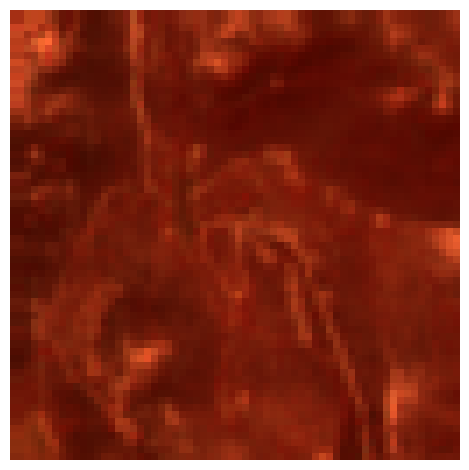

In [39]:
# False Color Check

new_band = [image_ms[7], image_ms[3], image_ms[2]]
ms_im8 = ms_visualisation_uint8(new_band)
    
plt.imshow(ms_im8)
plt.axis('off')

plt.savefig(MS_FALSE_CHECKS, dpi=300)

plt.tight_layout()
plt.show()
